> ⚠️ **LEGACY — fixed-τ 1BQF artefact (bannered 2026-07-06).** Any 1BQF (quantum)
> efficiency / false-rate in this notebook is computed at the **fixed τ=0.35 cut**, which
> pins the 1BQF at an artefactual **~70–75 % efficiency** (the cut chops the halved
> outer-true amplitude band — *the cut, not lost physics*). The project headline
> convention is **wp99** (efficiency-first working point; `Toy_Characterisation/WP99_REFRESH_LOG.md`).
> **Canonical replacement: `ERF/store_landscape.py`, `ERF/step_vs_erf_store.py`, `ERF/youden_eer_store.py` (store-backed).** Kept as a historical record; not maintained.

# ERF — Task 5: smooth angular cost with histogram-driven thresholds

**Hamiltonian**: $\mathcal{C}(\theta) = 1 + \mathrm{erf}\!\left(\frac{\varepsilon - \theta}{\theta_d\sqrt{2}}\right)$, `convolution=1`

**Grid**: $\theta_d \in \{10^{-6},10^{-5},5{\times}10^{-5},10^{-4},5{\times}10^{-4},10^{-3}\}$ × 3 noise pairs × $T \in \{10,20,50,100,200,400,700,1000\}$

**Regression check**: $\theta_d = 10^{-6}$ collapses to step function — should reproduce Phase 1/2 baseline.

## Sections
1. **Setup** — imports, grid, helpers
2. **Pickle inventory** — scan all results, completion table
3. **Hamiltonian structure** — $A_\mathrm{nnz}$ and fill fraction vs $\theta_d$
4. **Solution score spectra** — true/false amplitude distributions vs $\theta_d$ (mirrors §7b of Verify_new_results)
5. **Angle distributions** — raw pair angles with ERF cost overlay
6. **Histogram-driven thresholds** — Youden's J and EER per grid cell
7. **Segment metrics** — efficiency, purity, FAR vs $T$ coloured by $\theta_d$

In [1]:
# §1 Setup — imports, grid constants, plot style, shared helpers
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import erf as scipy_erf

HERE    = Path('.').resolve()
RESULTS = HERE / 'results'
FIGS    = HERE / 'figures'
FIGS.mkdir(exist_ok=True)

# Grid (mirrors gen_params.py)
THETA_D_GRID = [1e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3]
NOISE_GRID   = [(1e-4, 0.0), (3e-4, 0.01), (5e-4, 0.02)]
TRACK_GRID   = [10, 20, 50, 100, 200, 400, 700, 1000]
TAU          = 0.35  # default relative threshold (tau * max)

def reps_for_T(T): return 10 if T <= 50 else 5 if T <= 200 else 3

EXPECTED_TOTAL = (sum(reps_for_T(T) for T in TRACK_GRID)
                  * len(THETA_D_GRID) * len(NOISE_GRID))

# ── Plot style (matches Verify_new_results §1) ────────────────────────────────
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 9,
    'figure.titlesize': 15, 'axes.linewidth': 1.2,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'lines.linewidth': 2, 'lines.markersize': 6,
    'axes.grid': True, 'grid.alpha': 0.3,
})

c_true, c_false = '#1b7837', '#c51b7d'
c_cls,  c_qnt   = '#444444', '#2166ac'
TD_COLORS = plt.cm.plasma(np.linspace(0.1, 0.85, len(THETA_D_GRID)))
TD_LABELS = [
    r'$10^{-6}$ (step)', r'$10^{-5}$', r'$5\!\times\!10^{-5}$',
    r'$10^{-4}$',        r'$5\!\times\!10^{-4}$', r'$10^{-3}$',
]

def _style(ax):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.minorticks_on()

def _save(fig, stem):
    fig.savefig(FIGS / f'{stem}.pdf', bbox_inches='tight', facecolor='white')
    fig.savefig(FIGS / f'{stem}.png', dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  -> figures/{stem}.{{pdf,png}}')

def _err(ax, x, y, yerr, fmt='o-', **kw):
    return ax.errorbar(x, y, yerr=yerr, fmt=fmt,
                       capsize=4, capthick=1.5,
                       markeredgecolor='black', markeredgewidth=0.6,
                       zorder=3, **kw)

print(f'Grid: {len(THETA_D_GRID)} theta_d × {len(NOISE_GRID)} noise × {len(TRACK_GRID)} T '
      f'= {EXPECTED_TOTAL} total jobs')

Grid: 6 theta_d × 3 noise × 8 T = 882 total jobs


## §1b Local test run — $T \leq 50$, 3 reps, **inline**

Runs **in-process** (no subprocess): the library and Numba JIT compile once for the kernel session, then all 162 jobs reuse the warm kernels.

| T | Quantum? | Why |
|---|----------|-----|
| 10, 20 | ✓ yes | n_seg ~ 400–1600, 11–13 qubits, ~1–5 s/job |
| 50 | ✗ classical only | n_seg ~ 10,000 → 14-qubit HHL takes ~135 s/job on CPU — needs Condor GPU |

Estimated total: **~5–10 min** (sequential, single-threaded to keep Numba thread pool safe).  
After this cell finishes, **re-run §2** to load the new pickles.

In [2]:
# §1b Local test run — INLINE execution (no subprocess)
# Library and Numba JIT compile once per kernel session; all jobs reuse warm state.
# T=50 skips the quantum solver: n_seg~10,000 → 14-qubit CPU statevector ≈ 135 s/job.
# Quantum T=50 results will come from Condor GPU jobs.

import math, sys, time, pickle
from pathlib import Path

sys.path.insert(0, '/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src')
sys.path.insert(0, str(Path('/data/bfys/gscriven/Quantum_Track_Reconstruction'
                             '/Toy_Characterisation/_shared')))

import numpy as np

from lhcb_velo_toy.solvers import SimpleHamiltonianFast
from lhcb_velo_toy.analysis import compute_epsilon
from helpers import (
    make_geometry, safe_generate,
    solve_quantum_statevector, rescale_quantum,
    segment_truth_mask, solver_segment_metrics,
    fast_segment_metrics, collect_segment_pair_angles,
)

LOCAL_T    = [10, 20, 50]
LOCAL_REPS = 3
PHI_MAX    = 0.2
TAU_DEF    = 0.35

eps_map = {(ss, sr): compute_epsilon(sr, ss) for ss, sr in NOISE_GRID}
geom    = make_geometry()

# ── Numba JIT warmup ─────────────────────────────────────────────────────────
# First call compiles the Numba kernel; all subsequent jobs reuse the cache.
print('Warming up Numba JIT ...', end=' ', flush=True)
t_jit = time.time()
_wev = safe_generate(5, seed=99999, geom=geom, measurement_error=1e-4,
                     collision_noise=0.0, phi_max=PHI_MAX, theta_max=PHI_MAX)
fast_segment_metrics(_wev, 1e-3)
collect_segment_pair_angles(_wev)
print(f'done in {time.time() - t_jit:.1f} s')

# ── Build job list ────────────────────────────────────────────────────────────
jobs = []
for ss, sr in NOISE_GRID:
    eps = eps_map[(ss, sr)]
    for td in THETA_D_GRID:
        gridtag  = f"td{td:g}_ss{ss:g}_sr{sr:g}"
        cell_dir = RESULTS / gridtag
        cell_dir.mkdir(parents=True, exist_ok=True)
        for T in LOCAL_T:
            for rep in range(LOCAL_REPS):
                tag      = f"erf_{gridtag}"
                out_file = cell_dir / f"{tag}_n{T:04d}_r{rep:03d}.pkl"
                if out_file.exists():
                    continue
                jobs.append(dict(T=T, rep=rep, ss=ss, sr=sr, eps=eps, td=td,
                                 tag=tag, out_file=out_file,
                                 run_quantum=(T <= 20)))

total_expected = len(THETA_D_GRID) * len(NOISE_GRID) * len(LOCAL_T) * LOCAL_REPS
print(f'{len(jobs)} jobs queued  ({total_expected - len(jobs)} already done)')
if not jobs:
    print('Nothing to run — re-run §2 to reload ev.')
else:
    # ── Run jobs (sequential — keeps Numba thread pool conflict-free) ─────────
    ok = failed = 0
    t_start = time.time()

    for i, j in enumerate(jobs, 1):
        T, rep = j['T'], j['rep']
        ss, sr, eps, td = j['ss'], j['sr'], j['eps'], j['td']
        tag, out_file, run_quantum = j['tag'], j['out_file'], j['run_quantum']

        t0 = time.time()
        try:
            seed = rep + T * 100 + 200_000

            ev = safe_generate(T, seed=seed, geom=geom,
                               measurement_error=float(sr),
                               collision_noise=float(ss),
                               phi_max=PHI_MAX, theta_max=PHI_MAX)

            m_angle      = fast_segment_metrics(ev, float(eps))
            ta_raw, fa_raw = collect_segment_pair_angles(ev)
            true_angles  = np.asarray(ta_raw,  dtype=np.float64)
            false_angles = np.asarray(fa_raw, dtype=np.float64)

            ham = SimpleHamiltonianFast(
                epsilon=float(eps), gamma=3.0, delta=1.0, theta_d=float(td))
            ham.construct_segments(ev)
            ham.construct_hamiltonian(ev, convolution=True)
            sol_C = np.asarray(ham.solve_classicaly()).ravel()
            truth = segment_truth_mask(ham)

            A_nnz = int(ham.A.nnz) if hasattr(ham.A, 'nnz') else int(np.count_nonzero(ham.A))
            n_seg = int(ham.n_segments)
            n_pad = 1 << int(math.ceil(math.log2(max(n_seg, 2))))

            max_C      = float(np.max(sol_C)) if sol_C.size else 0.0
            mC_default = solver_segment_metrics(truth, sol_C, threshold=TAU_DEF * max_C)

            sol_Q = P_anc = n_sys = mQ_default = cos_QC = None
            t_q = 0.0
            if run_quantum:
                t_q0 = time.time()
                sol_Q_raw, P_anc, n_sys = solve_quantum_statevector(ham.A, ham.b, device='CPU')
                sol_Q  = rescale_quantum(sol_Q_raw, sol_C)
                t_q    = time.time() - t_q0
                max_Q  = float(np.max(sol_Q)) if sol_Q.size else 0.0
                mQ_default = solver_segment_metrics(truth, sol_Q, threshold=TAU_DEF * max_Q)
                if sol_Q.size and sol_C.size:
                    cos_QC = float(np.dot(sol_Q, sol_C)
                                   / (np.linalg.norm(sol_Q) * np.linalg.norm(sol_C) + 1e-30))

            record = dict(
                status='ok',
                n_trk=T, rep=rep, seed=seed, tag=tag,
                sigma_res=float(sr), sigma_scatt=float(ss),
                phi_max=PHI_MAX, hit_ineff=0.0,
                convolution=True, erf_sigma=float(td),
                epsilon=float(eps), gamma=3.0, delta=1.0, tau_default=TAU_DEF,
                n_seg=n_seg, n_pad=n_pad, A_nnz=A_nnz,
                n_qubits=(int(n_sys) + 2) if n_sys is not None else None,
                angle_metrics=m_angle,
                classical_metrics_default=mC_default,
                quantum_metrics_default=mQ_default,
                cos_QC=cos_QC, P_anc=P_anc,
                device='CPU',
                sol_C=sol_C, sol_Q=sol_Q, truth=truth,
                true_angles=true_angles, false_angles=false_angles,
                t_total=time.time() - t0,
            )
            with open(out_file, 'wb') as f:
                pickle.dump(record, f)

            eff_str = f"effC={mC_default['segment_efficiency']:.3f}"
            if mQ_default:
                eff_str += f" effQ={mQ_default['segment_efficiency']:.3f}"
            q_note = f"Q={t_q:.1f}s" if run_quantum else "Q=skip(GPU)"
            print(f"  [{i:3d}/{len(jobs)}] T={T:3d} rep={rep} td={td:.0e} "
                  f"n_seg={n_seg:5d} {eff_str} {q_note} "
                  f"t={time.time()-t0:.1f}s", flush=True)
            ok += 1

        except Exception as exc:
            import traceback as _tb
            print(f"  FAIL [{i}/{len(jobs)}] T={T} rep={rep} td={td:.0e}: {exc}")
            _tb.print_exc()
            failed += 1

    elapsed = time.time() - t_start
    print(f'\nDone — {ok}/{len(jobs)} ok, {failed} failed in '
          f'{elapsed:.0f} s  ({elapsed / max(ok + failed, 1):.1f} s/job)')
    print('Re-run §2 to load results.')

Warming up Numba JIT ... 

done in 0.4 s
0 jobs queued  (162 already done)
Nothing to run — re-run §2 to reload ev.


In [3]:
# §2 Scan all pickles → event DataFrame
def _f(v):
    """Convert value to float, mapping None and non-finite to NaN."""
    try:
        x = float(v)
        return x
    except (TypeError, ValueError):
        return np.nan

def scan_all_pickles(results_dir):
    rows = []
    for pkl in sorted(results_dir.glob('**/*.pkl')):
        try:
            r = pickle.load(open(pkl, 'rb'))
        except Exception:
            continue
        if r.get('status') != 'ok':
            continue
        mC = r.get('classical_metrics_default') or {}
        mQ = r.get('quantum_metrics_default')   or {}
        rows.append(dict(
            file        = str(pkl),
            n_trk       = int(r['n_trk']),
            rep         = int(r['rep']),
            erf_sigma   = float(r['erf_sigma']),
            sigma_scatt = float(r['sigma_scatt']),
            sigma_res   = float(r['sigma_res']),
            n_seg       = int(r.get('n_seg', 0)),
            A_nnz       = _f(r.get('A_nnz')),
            cls_eff     = _f(mC.get('segment_efficiency')),
            cls_pur     = _f(mC.get('segment_purity')),
            cls_far     = _f(mC.get('segment_false_rate')),
            q_eff       = _f(mQ.get('segment_efficiency')) if mQ else np.nan,
            q_pur       = _f(mQ.get('segment_purity'))     if mQ else np.nan,
            q_far       = _f(mQ.get('segment_false_rate')) if mQ else np.nan,
            cos_QC      = _f(r.get('cos_QC')),   # None for T=50 (quantum skipped)
            P_anc       = _f(r.get('P_anc')),
            t_total     = _f(r.get('t_total')),
        ))
    if not rows:
        return pd.DataFrame()
    return (pd.DataFrame(rows)
            .sort_values(['erf_sigma','sigma_scatt','sigma_res','n_trk','rep'])
            .reset_index(drop=True))

ev = scan_all_pickles(RESULTS)
if ev.empty:
    print('No completed pickles yet — Condor jobs still running.')
else:
    print(f'{len(ev)} events loaded')
    print(f'erf_sigma values : {sorted(ev.erf_sigma.unique())}')
    print(f'n_trk values     : {sorted(ev.n_trk.unique())}')
    print(f'noise pairs      : {sorted(set(zip(ev.sigma_scatt, ev.sigma_res)))}')
    q_rows = ev.cos_QC.notna().sum()
    print(f'rows with quantum solution: {q_rows} / {len(ev)}')

162 events loaded
erf_sigma values : [np.float64(1e-06), np.float64(1e-05), np.float64(5e-05), np.float64(0.0001), np.float64(0.0005), np.float64(0.001)]
n_trk values     : [np.int64(10), np.int64(20), np.int64(50)]
noise pairs      : [(0.0001, 0.0), (0.0003, 0.01), (0.0005, 0.02)]
rows with quantum solution: 108 / 162


In [4]:
# §2b Completion status table
expected_df = pd.DataFrame([
    dict(erf_sigma=td, sigma_scatt=ss, sigma_res=sr, n_trk=T, expected=reps_for_T(T))
    for td in THETA_D_GRID for ss, sr in NOISE_GRID for T in TRACK_GRID
])

if ev.empty:
    done_df = pd.DataFrame(columns=['erf_sigma','sigma_scatt','sigma_res','n_trk','n_done'])
else:
    done_df = (ev.groupby(['erf_sigma','sigma_scatt','sigma_res','n_trk'])
               .size().rename('n_done').reset_index())

status = (expected_df
          .merge(done_df, how='left')
          .fillna({'n_done': 0})
          .assign(n_done=lambda d: d['n_done'].astype(int),
                  pct=lambda d: (100 * d['n_done'] / d['expected']).round(0).astype(int)))

total_done = int(status['n_done'].sum())
print(f'Overall: {total_done} / {EXPECTED_TOTAL} ({100*total_done/EXPECTED_TOTAL:.0f}%)')

incomplete = status[status['n_done'] < status['expected']]
if incomplete.empty:
    print('All grid cells complete!')
else:
    # Pivot to a compact view: rows = (erf_sigma, noise), cols = n_trk
    piv = (status.pivot_table(
        index=['erf_sigma','sigma_scatt','sigma_res'],
        columns='n_trk', values='pct', aggfunc='first')
           .reset_index())
    print(piv.to_string(index=False))

Overall: 162 / 882 (18%)
 erf_sigma  sigma_scatt  sigma_res  10  20  50  100  200  400  700  1000
  0.000001       0.0001       0.00  30  30  30    0    0    0    0     0
  0.000001       0.0003       0.01  30  30  30    0    0    0    0     0
  0.000001       0.0005       0.02  30  30  30    0    0    0    0     0
  0.000010       0.0001       0.00  30  30  30    0    0    0    0     0
  0.000010       0.0003       0.01  30  30  30    0    0    0    0     0
  0.000010       0.0005       0.02  30  30  30    0    0    0    0     0
  0.000050       0.0001       0.00  30  30  30    0    0    0    0     0
  0.000050       0.0003       0.01  30  30  30    0    0    0    0     0
  0.000050       0.0005       0.02  30  30  30    0    0    0    0     0
  0.000100       0.0001       0.00  30  30  30    0    0    0    0     0
  0.000100       0.0003       0.01  30  30  30    0    0    0    0     0
  0.000100       0.0005       0.02  30  30  30    0    0    0    0     0
  0.000500       0.0001   

## §3 Hamiltonian structure — $A_\mathrm{nnz}$ vs $\theta_d$

With `convolution=False` (step function) only segment pairs with $\theta < \varepsilon$ contribute off-diagonal entries.  
With `convolution=True` (ERF) **all** pairs contribute, weighted by $1+\mathrm{erf}((\varepsilon-\theta)/\theta_d\sqrt{2})$.  
Near-zero weights for $\theta \gg \varepsilon$ are still written, so $A_\mathrm{nnz}$ should be $\propto n_\mathrm{seg}^2$ for all $\theta_d$ — but the fill fraction is identical across $\theta_d$ values (ERF doesn't sparsify; it smooths).  
The key question: does the **condition number** change with $\theta_d$, making the quantum solver easier or harder?

  -> figures/ham_structure_vs_td.{pdf,png}


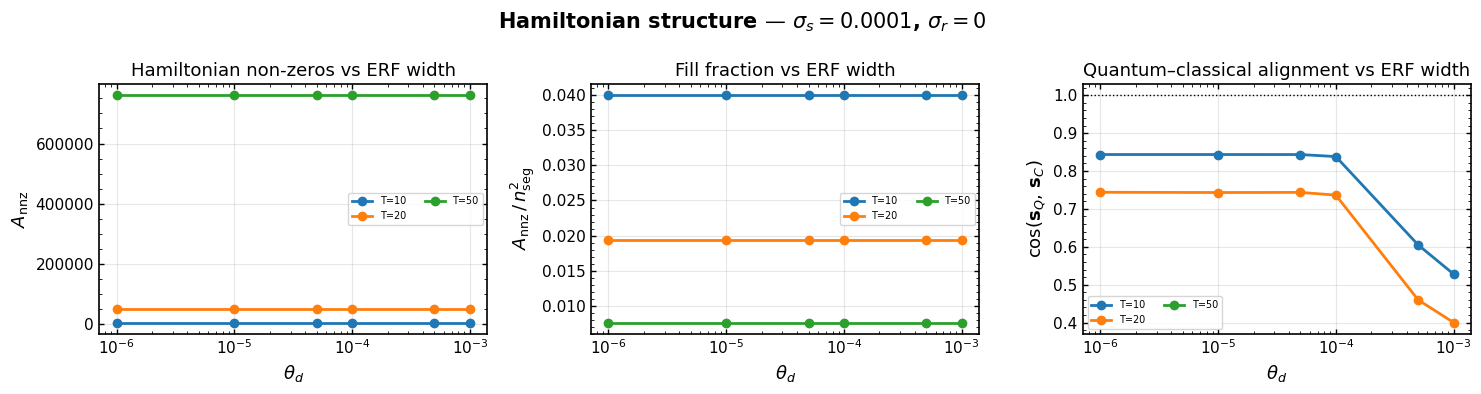

In [5]:
# §3 Hamiltonian structure — A_nnz, fill fraction, cos(Q,C) vs erf_sigma
if ev.empty:
    print('No data yet.')
else:
    g = (ev.groupby(['erf_sigma', 'sigma_scatt', 'sigma_res', 'n_trk'])
         .agg(A_nnz_mean=('A_nnz', 'mean'),
              n_seg_mean =('n_seg', 'mean'),
              cos_mean   =('cos_QC','mean'),
              n_reps     =('rep',  'count'))
         .reset_index())
    g['fill'] = g['A_nnz_mean'] / g['n_seg_mean']**2

    # Plot for the lowest-noise pair only (cleanest signal)
    ss0, sr0 = NOISE_GRID[0]
    gp = g[(g.sigma_scatt == ss0) & (g.sigma_res == sr0)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ax = axes[0]
    for T, sub in gp.groupby('n_trk'):
        ax.plot(sub['erf_sigma'], sub['A_nnz_mean'], 'o-', label=f'T={T}')
    ax.set_xscale('log'); ax.set_xlabel(r'$\theta_d$')
    ax.set_ylabel(r'$A_\mathrm{nnz}$')
    ax.set_title('Hamiltonian non-zeros vs ERF width')
    ax.legend(fontsize=7, ncol=2); _style(ax)

    ax = axes[1]
    for T, sub in gp.groupby('n_trk'):
        ax.plot(sub['erf_sigma'], sub['fill'], 'o-', label=f'T={T}')
    ax.set_xscale('log'); ax.set_xlabel(r'$\theta_d$')
    ax.set_ylabel(r'$A_\mathrm{nnz}\,/\,n_\mathrm{seg}^2$')
    ax.set_title('Fill fraction vs ERF width')
    ax.legend(fontsize=7, ncol=2); _style(ax)

    ax = axes[2]
    for T, sub in gp.groupby('n_trk'):
        ax.plot(sub['erf_sigma'], sub['cos_mean'], 'o-', label=f'T={T}')
    ax.axhline(1.0, color='k', ls=':', lw=1)
    ax.set_xscale('log'); ax.set_xlabel(r'$\theta_d$')
    ax.set_ylabel(r'$\cos(\mathbf{s}_Q,\,\mathbf{s}_C)$')
    ax.set_title(r'Quantum–classical alignment vs ERF width')
    ax.legend(fontsize=7, ncol=2); _style(ax)

    fig.suptitle(fr'Hamiltonian structure — $\sigma_s={ss0:g}$, $\sigma_r={sr0:g}$',
                 fontweight='bold')
    fig.tight_layout()
    _save(fig, 'ham_structure_vs_td')
    plt.show()

## §3b A-matrix eigenspectrum and weight structure

The A matrix is **not stored** in the pickles (too large), but it can be reconstructed cheaply for small events.
We use T=10, rep=0, noise pair 0 — the exact same seed as the existing pickles — so the event geometry is identical.

With `convolution=True` the **sparsity pattern is fixed** (all segment pairs that share a mid-hit get an entry regardless of θ_d); only the off-diagonal **values** change:

$$w_{ij} = 1 + \mathrm{erf}\!\left(\frac{\varepsilon - \theta_{ij}}{\theta_d\sqrt{2}}\right) \in [0, 2]$$

- $\theta_d \to 0$ (step limit): binary values near 0 or 2 — identical structure to Phase 1/2 Hamiltonian scaled by 2
- $\theta_d = 10^{-3}$: smooth continuous weights; near-$\varepsilon$ pairs get intermediate values

The eigenspectrum of A controls HHL circuit depth and success probability.
$\kappa = \lambda_\max / \lambda_{\min,+}$ is the condition number — higher means harder for the quantum solver.

epsilon = 4.2479e-04 rad   (pairs within eps get weight ~2; false pairs at ~0.05-0.2 rad get 0)

   theta_d     lmin+      lmax     kappa            diag_rng          coupling_rng
   1.0e-06    0.7639    7.2361       9.5    [4.000, 4.000]    [-2.0000, -2.0000]  n=60
   1.0e-05    0.7639    7.2361       9.5    [4.000, 4.000]    [-2.0000, -2.0000]  n=60
   5.0e-05    0.7639    7.2361       9.5    [4.000, 4.000]    [-2.0000, -1.9999]  n=60
   1.0e-04    0.7648    7.2352       9.5    [4.000, 4.000]    [-1.9999, -1.9511]  n=60
   5.0e-04    1.5432    6.4568       4.2    [4.000, 4.000]    [-1.5825, -1.3064]  n=60
   1.0e-03    1.9368    6.0632       3.1    [4.000, 4.000]    [-1.3148, -1.1561]  n=60

Note: off-diagonal entries are negative (attractive coupling between compatible segments).
ERF widens the step → reduces coupling magnitude → compresses eigenvalue spread → lower κ.


  -> figures/A_heatmap_td_comparison.{pdf,png}


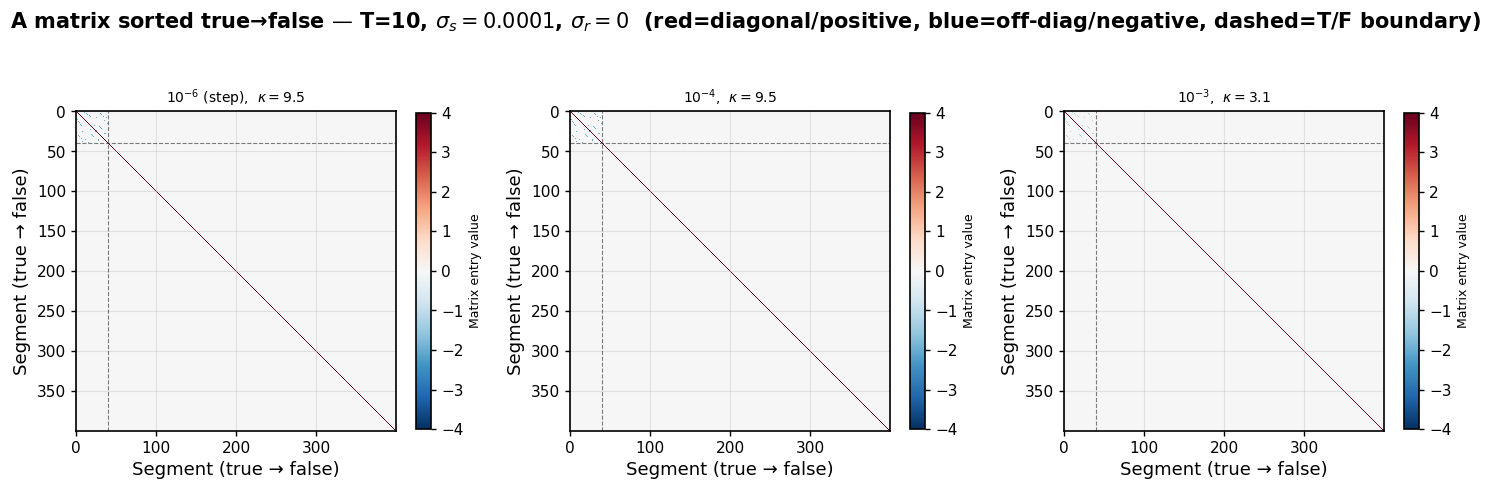

  -> figures/eigspectrum_summary.{pdf,png}


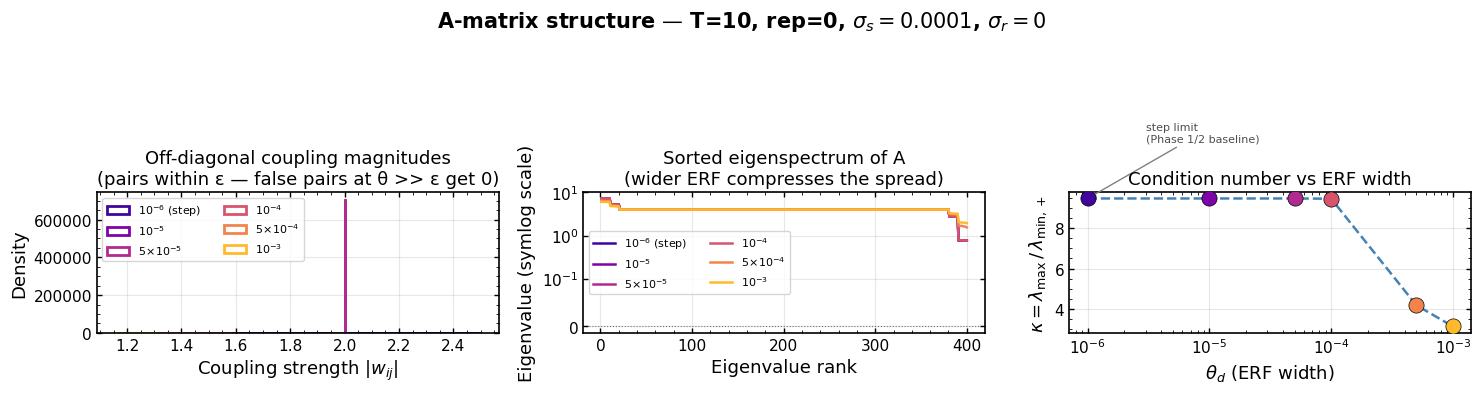

In [6]:
# §3b  Reconstruct A for T=10 (all theta_d), compute eigenspectrum & weight distribution
import sys, numpy as np, scipy.sparse as sp, matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, '/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src')
sys.path.insert(0, str(Path('/data/bfys/gscriven/Quantum_Track_Reconstruction'
                             '/Toy_Characterisation/_shared')))
from lhcb_velo_toy.solvers import SimpleHamiltonianFast
from lhcb_velo_toy.analysis import compute_epsilon
from helpers import make_geometry, safe_generate, segment_truth_mask

# Event matching pickle *_n0010_r000 for noise pair 0
_T, _rep   = 10, 0
_ss, _sr   = NOISE_GRID[0]
_eps       = compute_epsilon(_sr, _ss)
_seed      = _rep + _T * 100 + 200_000
_geom      = make_geometry()
_ev        = safe_generate(_T, seed=_seed, geom=_geom,
                           measurement_error=_sr, collision_noise=_ss,
                           phi_max=0.2, theta_max=0.2)

print(f"epsilon = {_eps:.4e} rad   (pairs within eps get weight ~2; false pairs at ~0.05-0.2 rad get 0)")

# ── Reconstruct A for every theta_d ─────────────────────────────────────────
eig_data = {}
print(f"\n{'theta_d':>10}  {'lmin+':>8}  {'lmax':>8}  {'kappa':>8}  "
      f"{'diag_rng':>18}  {'coupling_rng':>20}")
for td in THETA_D_GRID:
    ham = SimpleHamiltonianFast(epsilon=_eps, gamma=3.0, delta=1.0, theta_d=float(td))
    ham.construct_segments(_ev)
    ham.construct_hamiltonian(_ev, convolution=True)
    A   = ham.A.toarray() if sp.issparse(ham.A) else np.asarray(ham.A, dtype=float)
    tr  = np.asarray(segment_truth_mask(ham), dtype=bool)

    diag  = np.diag(A)
    A_off = A.copy(); np.fill_diagonal(A_off, 0.0)
    nz_w  = A_off[np.abs(A_off) > 1e-12]   # off-diagonal coupling values (negative = attractive)

    _eigv = np.linalg.eigvalsh(A)
    floor = 1e-10 * max(float(_eigv.max()), 1.0)
    pos   = _eigv[_eigv > floor]
    kap   = float(pos.max() / pos.min()) if pos.size > 1 else np.inf

    eig_data[td] = dict(A=A, truth=tr, eigvals=_eigv, nz_weights=nz_w,
                        kappa=kap, diag=diag)
    print(f"  {td:>8.1e}  {pos.min():>8.4f}  {_eigv.max():>8.4f}  {kap:>8.1f}  "
          f"  [{diag.min():.3f}, {diag.max():.3f}]  "
          f"  [{nz_w.min():.4f}, {nz_w.max():.4f}]  n={len(nz_w)}")

print("\nNote: off-diagonal entries are negative (attractive coupling between compatible segments).")
print("ERF widens the step → reduces coupling magnitude → compresses eigenvalue spread → lower κ.")

# ── Figure 1: A-matrix heatmaps sorted true→false ────────────────────────────
# Diverging colormap centred at 0: negative = blue (attractive), positive = red (diagonal)
SHOW_TDS = [THETA_D_GRID[0], THETA_D_GRID[3], THETA_D_GRID[-1]]   # 1e-6, 1e-4, 1e-3
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
for ax, td in zip(axes1, SHOW_TDS):
    d    = eig_data[td]
    idx  = np.argsort(~d['truth'])    # true segments first
    A_s  = d['A'][np.ix_(idx, idx)]
    vlim = max(abs(A_s.min()), abs(A_s.max()))
    im   = ax.imshow(A_s, origin='upper', cmap='RdBu_r',
                     vmin=-vlim, vmax=vlim,
                     interpolation='nearest', aspect='equal')
    n_t  = int(d['truth'].sum())
    ax.axhline(n_t - 0.5, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.axvline(n_t - 0.5, color='k', lw=0.8, ls='--', alpha=0.5)
    lab  = TD_LABELS[THETA_D_GRID.index(td)]
    kap  = d['kappa']
    ax.set_title(fr'{lab},  $\kappa={kap:.1f}$', fontsize=10)
    ax.set_xlabel('Segment (true → false)')
    ax.set_ylabel('Segment (true → false)')
    cb = plt.colorbar(im, ax=ax, shrink=0.75)
    cb.set_label('Matrix entry value', fontsize=9)

fig1.suptitle(fr'A matrix sorted true→false — T={_T}, $\sigma_s={_ss:g}$, $\sigma_r={_sr:g}$  '
              r'(red=diagonal/positive, blue=off-diag/negative, dashed=T/F boundary)',
              fontweight='bold')
fig1.tight_layout()
_save(fig1, 'A_heatmap_td_comparison')
plt.show()

# ── Figure 2: coupling strengths + eigenspectrum + κ ─────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1 — off-diagonal coupling magnitude distribution
ax = axes2[0]
for td, col, lab in zip(THETA_D_GRID, TD_COLORS, TD_LABELS):
    w = np.abs(eig_data[td]['nz_weights'])   # use magnitude (they're all negative)
    if w.size:
        ax.hist(w, bins=60, density=True, histtype='step', lw=2,
                color=col, label=lab)
ax.set_xlabel(r'Coupling strength $|w_{ij}|$')
ax.set_ylabel('Density')
ax.set_title('Off-diagonal coupling magnitudes\n(pairs within ε — false pairs at θ >> ε get 0)')
ax.legend(fontsize=8, ncol=2); _style(ax)

# Panel 2 — sorted eigenvalues
ax = axes2[1]
for td, col, lab in zip(THETA_D_GRID, TD_COLORS, TD_LABELS):
    ev_s = np.sort(eig_data[td]['eigvals'])[::-1]
    ax.plot(np.arange(1, len(ev_s) + 1), ev_s, color=col, lw=1.8,
            label=lab)
ax.axhline(0, color='k', ls=':', lw=0.8, alpha=0.5)
ax.set_yscale('symlog', linthresh=0.1)
ax.set_xlabel('Eigenvalue rank')
ax.set_ylabel('Eigenvalue (symlog scale)')
ax.set_title('Sorted eigenspectrum of A\n(wider ERF compresses the spread)')
ax.legend(fontsize=8, ncol=2); _style(ax)

# Panel 3 — condition number vs theta_d
ax = axes2[2]
kappas = [eig_data[td]['kappa'] for td in THETA_D_GRID]
ax.plot(THETA_D_GRID, kappas, 'o--', color='steelblue', lw=1.8, ms=9,
        markeredgecolor='k', markeredgewidth=0.5, zorder=5)
for td, kap, col in zip(THETA_D_GRID, kappas, TD_COLORS):
    ax.scatter([td], [kap], color=col, s=120, zorder=6, edgecolors='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$\theta_d$ (ERF width)')
ax.set_ylabel(r'$\kappa = \lambda_\max\,/\,\lambda_{\min,+}$')
ax.set_title(r'Condition number vs ERF width')
ax.annotate('step limit\n(Phase 1/2 baseline)', xy=(THETA_D_GRID[0], kappas[0]),
            xytext=(THETA_D_GRID[0] * 3, kappas[0] * 1.3),
            fontsize=8, color='0.3',
            arrowprops=dict(arrowstyle='->', color='0.5', lw=1))
_style(ax)

fig2.suptitle(fr'A-matrix structure — T={_T}, rep={_rep}, '
              fr'$\sigma_s={_ss:g}$, $\sigma_r={_sr:g}$',
              fontweight='bold')
fig2.tight_layout()
_save(fig2, 'eigspectrum_summary')
plt.show()

## §4 Solution score spectra — true vs false amplitude distributions

Mirrors §7b of `Verify_new_results/Quantum_segment_level_analysis.ipynb`.

For each $\theta_d$ value we pool $s_C[\mathrm{true}]$ vs $s_C[\mathrm{false}]$ (and the quantum equivalent) across the low-$T$ events where the distributions are cleanest.

With the step function ($\theta_d = 10^{-6}$): the classical solution assigns high scores to the $\varepsilon$-compatible true segments only → sharp separation.  
With wider $\theta_d$: the ERF cost assigns non-zero Hamiltonian coupling to all pairs → the solver must trade off more off-diagonal entries → the score gap may narrow.  
The **regression check** is that the $\theta_d = 10^{-6}$ panel reproduces the Phase 1/2 step-function spectrum.

  -> figures/score_spectrum_by_td.{pdf,png}


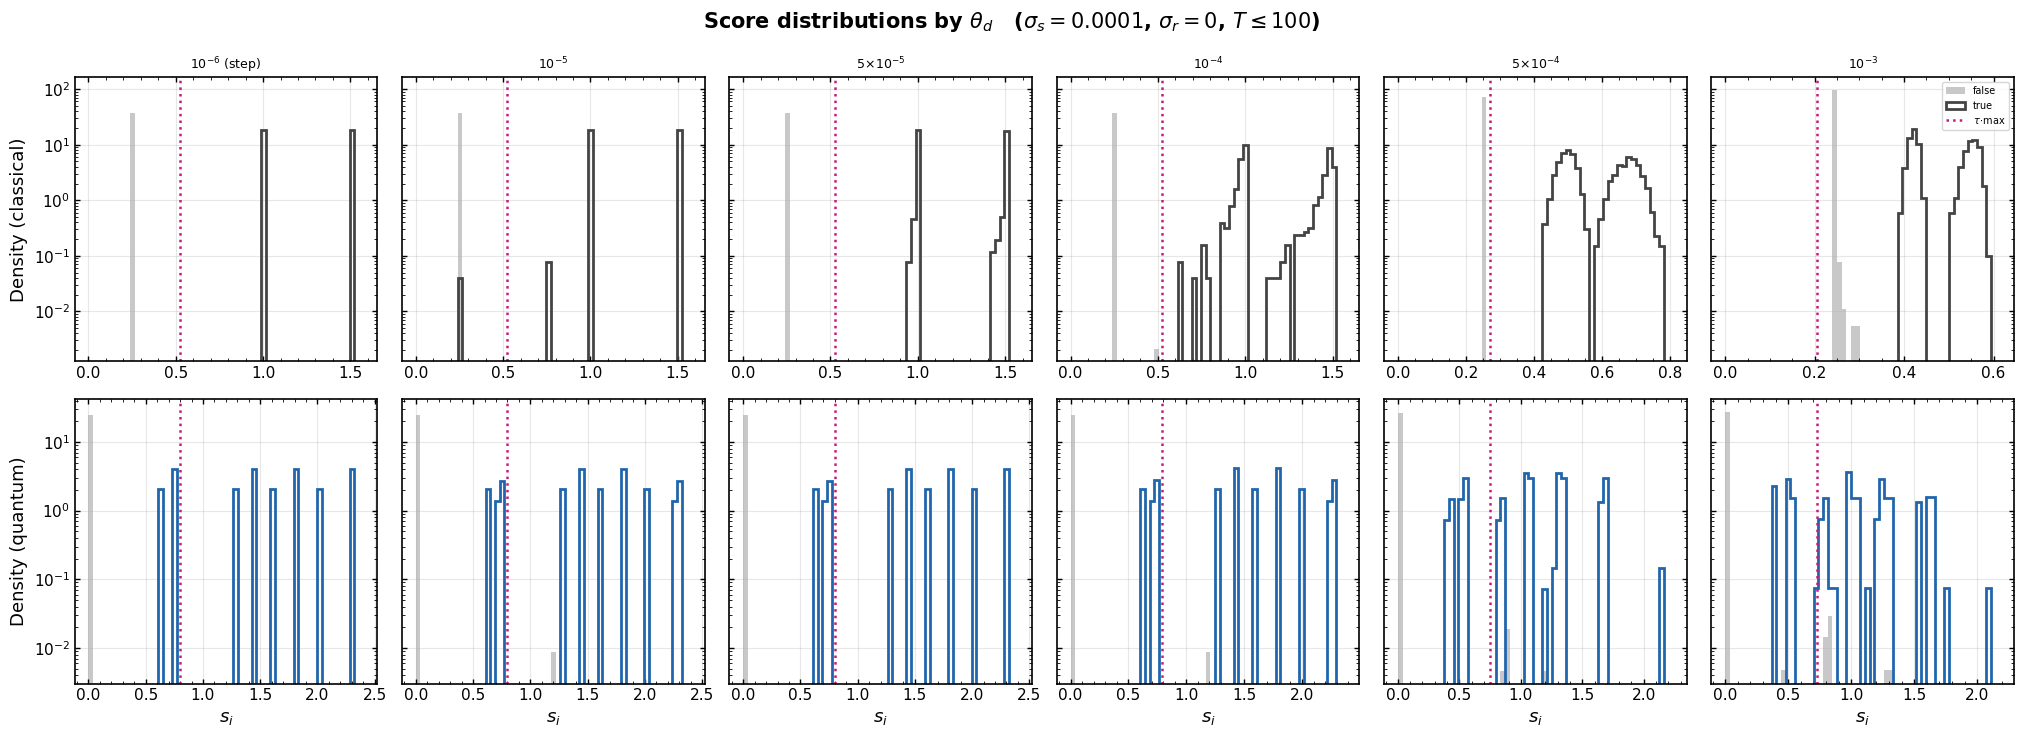

In [7]:
# §4a Pool scores from pkl files (mirrors _pool_amps in Verify_new_results §7b)
def pool_scores_by_td(results_dir, sigma_scatt, sigma_res,
                      n_trk_select=None, max_per_cell=5):
    """
    Return {erf_sigma: {sC_true, sC_false, sQ_true, sQ_false}}
    Reads sol_C / sol_Q / truth directly from pickles.
    """
    T_sel = set(n_trk_select) if n_trk_select else set(TRACK_GRID)
    out = {}
    for td in THETA_D_GRID:
        tag_dir = results_dir / f"td{td:g}_ss{sigma_scatt:g}_sr{sigma_res:g}"
        pkls = sorted(tag_dir.glob('*.pkl')) if tag_dir.exists() else []
        sC_t, sC_f, sQ_t, sQ_f = [], [], [], []
        count = 0
        for fp in pkls:
            if count >= max_per_cell * len(T_sel):
                break
            try:
                r = pickle.load(open(fp, 'rb'))
            except Exception:
                continue
            if r.get('status') != 'ok':
                continue
            if r['n_trk'] not in T_sel:
                continue
            sC = np.asarray(r['sol_C'])
            tr = np.asarray(r['truth'], dtype=bool)
            sC_t.append(sC[tr]);  sC_f.append(sC[~tr])
            if r.get('sol_Q') is not None:
                sQ = np.asarray(r['sol_Q'])
                sQ_t.append(sQ[tr]); sQ_f.append(sQ[~tr])
            count += 1
        if sC_t:
            out[td] = dict(
                sC_true  = np.concatenate(sC_t),
                sC_false = np.concatenate(sC_f),
                sQ_true  = np.concatenate(sQ_t)  if sQ_t else None,
                sQ_false = np.concatenate(sQ_f)  if sQ_f else None,
            )
    return out

ss0, sr0  = NOISE_GRID[0]                      # cleanest noise pair
LOW_T     = [T for T in TRACK_GRID if T <= 100]  # low-occ only for clean spectra
pools     = pool_scores_by_td(RESULTS, ss0, sr0, n_trk_select=LOW_T)

if not pools:
    print('No pickles found — run after Condor jobs complete.')
else:
    n_td = len(THETA_D_GRID)
    fig, axes = plt.subplots(2, n_td, figsize=(3.4 * n_td, 7.5),
                             sharey='row', sharex=False)

    for j, (td, col, lab) in enumerate(zip(THETA_D_GRID, TD_COLORS, TD_LABELS)):
        if td not in pools:
            for ax in axes[:, j]: ax.set_visible(False)
            continue
        p = pools[td]

        # ── row 0: classical ─────────────────────────────────────────────────
        ax = axes[0, j]
        hi = float(max(p['sC_true'].max(), p['sC_false'].max())) * 1.05
        bins = np.linspace(0, hi, 60)
        ax.hist(p['sC_false'], bins=bins, color='0.75', alpha=0.85,
                label='false', density=True)
        ax.hist(p['sC_true'],  bins=bins, color=c_cls, histtype='step',
                lw=2.0, label='true', density=True)
        tau_line = TAU * float(p['sC_true'].max())
        ax.axvline(tau_line, color=c_false, ls=':', lw=1.8,
                   label=r'$\tau\!\cdot\!\max$')
        ax.set_yscale('log')
        ax.set_title(lab, fontsize=9)
        if j == 0:         ax.set_ylabel('Density (classical)')
        if j == n_td - 1:  ax.legend(fontsize=7, loc='upper right')
        _style(ax)

        # ── row 1: quantum ───────────────────────────────────────────────────
        ax = axes[1, j]
        if p['sQ_true'] is not None and len(p['sQ_true']):
            hi = float(max(p['sQ_true'].max(), p['sQ_false'].max())) * 1.05
            bins = np.linspace(0, hi, 60)
            ax.hist(p['sQ_false'], bins=bins, color='0.75', alpha=0.85, density=True)
            ax.hist(p['sQ_true'],  bins=bins, color=c_qnt, histtype='step',
                    lw=2.0, density=True)
            ax.axvline(TAU * float(p['sQ_true'].max()), color=c_false,
                       ls=':', lw=1.8)
        ax.set_yscale('log'); ax.set_xlabel(r'$s_i$')
        if j == 0: ax.set_ylabel('Density (quantum)')
        _style(ax)

    fig.suptitle(fr'Score distributions by $\theta_d$   '
                 fr'($\sigma_s={ss0:g}$, $\sigma_r={sr0:g}$, $T \leq {max(LOW_T)}$)',
                 fontweight='bold')
    fig.tight_layout()
    _save(fig, 'score_spectrum_by_td')
    plt.show()

## §4b Per-event sorted activation spectrum

The pooled histograms above (§4a) show the aggregate picture.
Here we look at a **single representative event** for each $\theta_d$: segments sorted by score, colour-coded true/false.

This shows directly:
- How large is the score gap between true and false segments?
- Does the ERF create a clean rank-ordering, or does it mix true/false together?
- Regression: $\theta_d = 10^{-6}$ should give a clean two-level step (all true segments rank above all false ones at T=10).

We also overlay a 1-D scatter of scores to show the true/false separation quantitatively for all three T values in the local run.

  -> figures/activation_sorted_T10.{pdf,png}


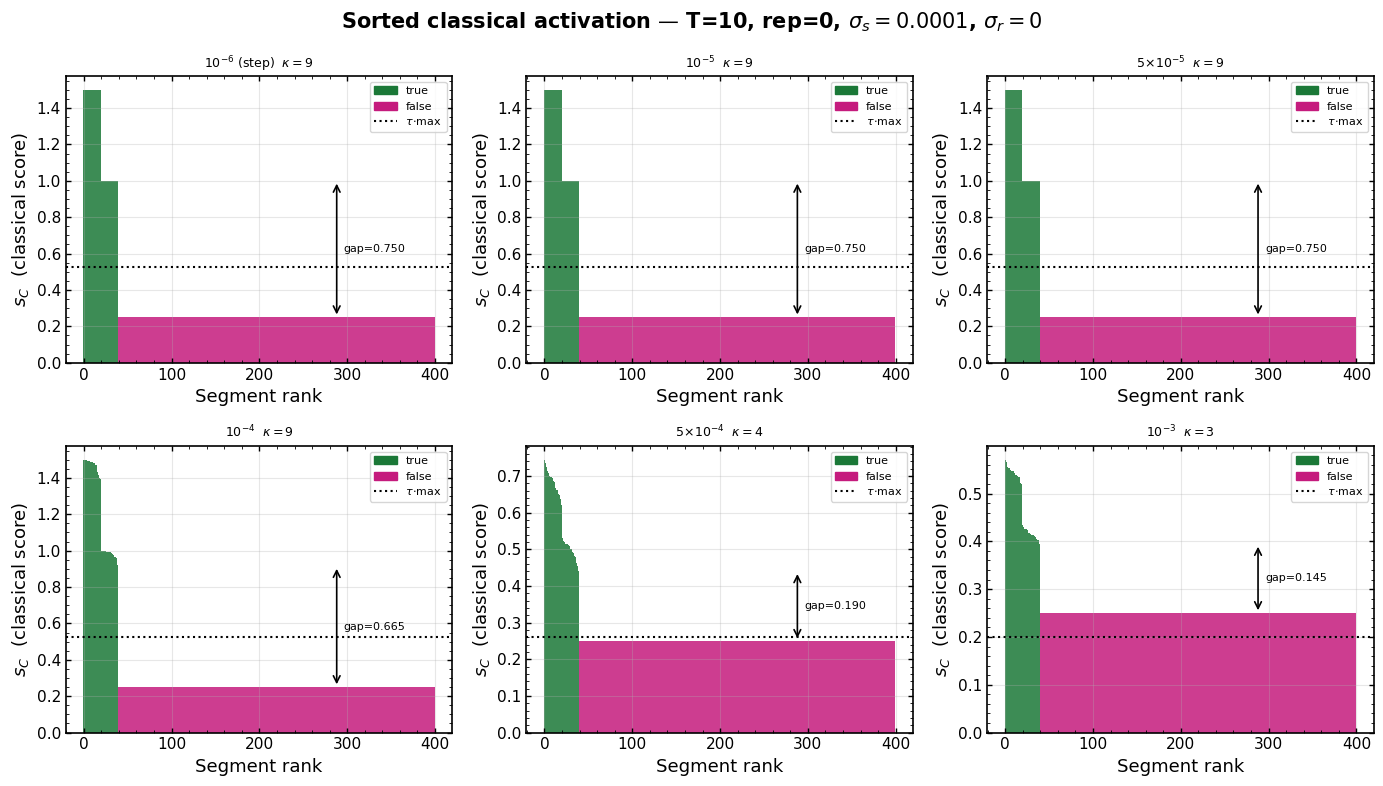

  -> figures/activation_scatter_T_vs_td.{pdf,png}


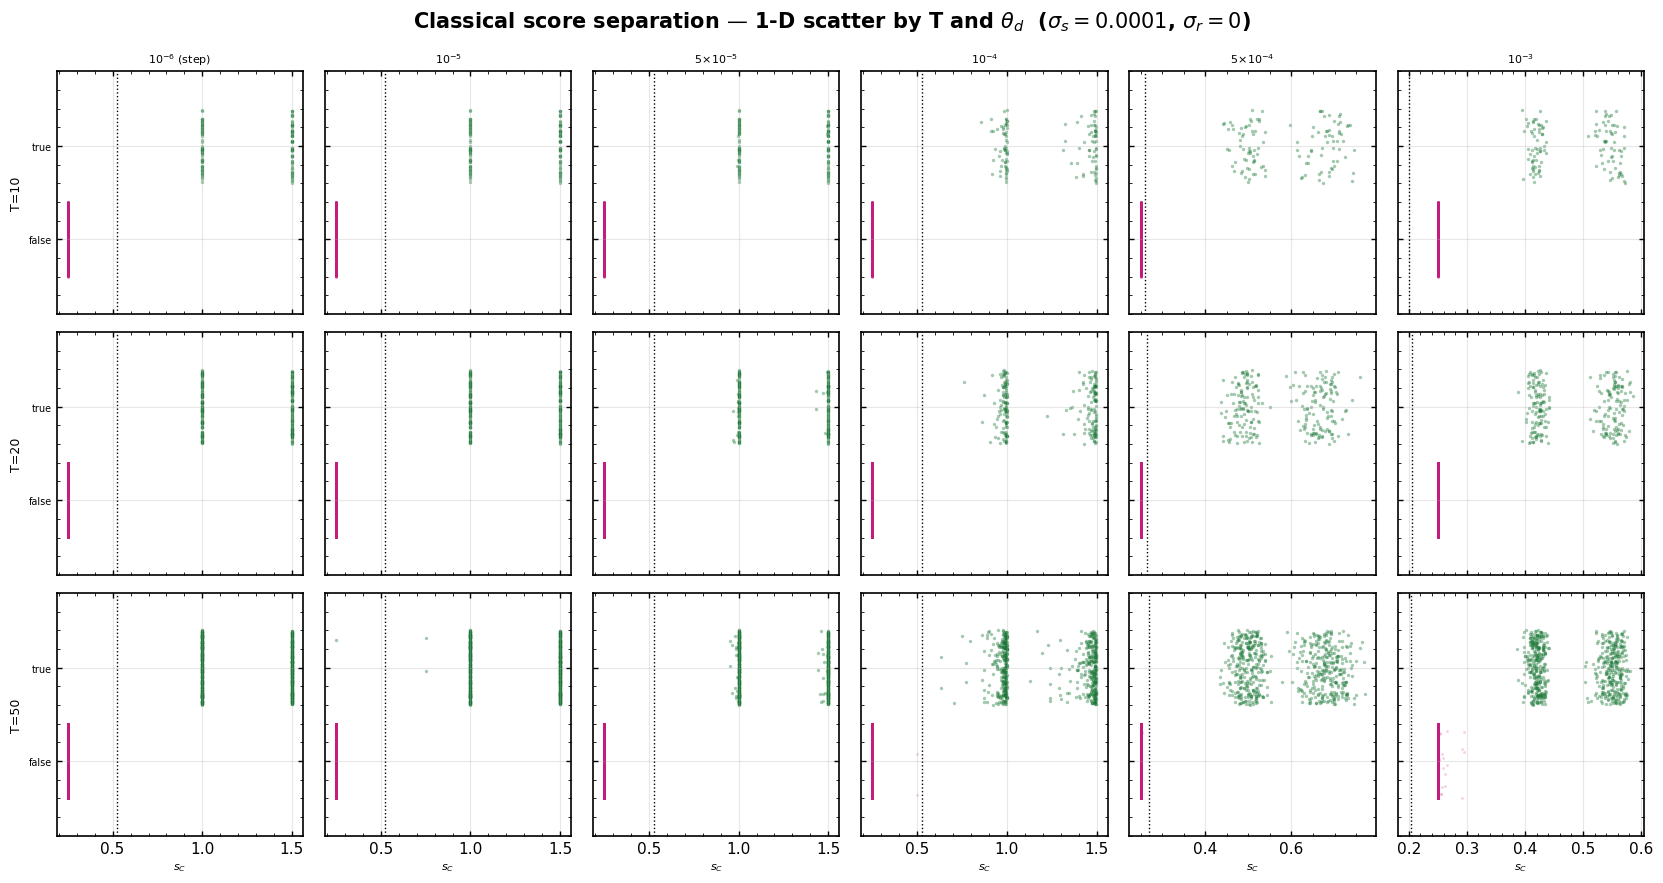

In [8]:
# §4b Sorted activation spectrum — one event per theta_d + T-sweep 1-D scatter
import pickle, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

ss0, sr0 = NOISE_GRID[0]   # cleanest noise pair

def _kappa_label(td):
    try:
        return fr'  $\kappa={eig_data[td]["kappa"]:.0f}$'
    except (NameError, KeyError):
        return ''

# ── Figure 1: sorted sol_C for T=10 rep=0 across all theta_d ─────────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(14, 8), sharex=False, sharey=False)
axes1 = axes1.ravel()

for j, (td, col, lab) in enumerate(zip(THETA_D_GRID, TD_COLORS, TD_LABELS)):
    ax = axes1[j]
    cell_dir = RESULTS / f"td{td:g}_ss{ss0:g}_sr{sr0:g}"
    pkls = sorted(cell_dir.glob('*_n0010_r000.pkl'))
    if not pkls:
        ax.set_visible(False); continue

    r     = pickle.load(open(pkls[0], 'rb'))
    sC    = np.asarray(r['sol_C'])
    tr    = np.asarray(r['truth'], dtype=bool)
    order = np.argsort(sC)[::-1]           # highest score first
    sC_s  = sC[order]
    tr_s  = tr[order]

    bar_colors = np.where(tr_s, c_true, c_false)
    ax.bar(np.arange(len(sC_s)), sC_s, color=bar_colors, alpha=0.85, width=1.0)
    ax.axhline(TAU * sC_s.max(), color='k', ls=':', lw=1.5)

    t_min = sC[tr].min() if tr.any() else np.nan
    f_max = sC[~tr].max() if (~tr).any() else np.nan
    if np.isfinite(t_min) and np.isfinite(f_max):
        gap = t_min - f_max
        ax.annotate('', xy=(len(tr_s) * 0.72, f_max),
                    xytext=(len(tr_s) * 0.72, t_min),
                    arrowprops=dict(arrowstyle='<->', color='k', lw=1.2))
        ax.text(len(tr_s) * 0.74, (t_min + f_max) / 2,
                f'gap={gap:.3f}', fontsize=8, va='center')

    ax.set_title(fr'{lab}{_kappa_label(td)}', fontsize=9)
    ax.set_xlabel('Segment rank')
    ax.set_ylabel('$s_C$  (classical score)')
    ax.legend(handles=[Patch(color=c_true, label='true'),
                        Patch(color=c_false, label='false'),
                        plt.Line2D([0],[0], color='k', ls=':', lw=1.5,
                                   label=fr'$\tau\!\cdot\!\max$')],
              fontsize=8, loc='upper right')
    _style(ax)

fig1.suptitle(fr'Sorted classical activation — T=10, rep=0, '
              fr'$\sigma_s={ss0:g}$, $\sigma_r={sr0:g}$',
              fontweight='bold')
fig1.tight_layout()
_save(fig1, 'activation_sorted_T10')
plt.show()

# ── Figure 2: 1-D score scatter (true vs false) — T × theta_d grid ───────────
LOCAL_T_VALS = [10, 20, 50]
n_td = len(THETA_D_GRID)
fig2, axes2 = plt.subplots(len(LOCAL_T_VALS), n_td,
                            figsize=(2.8 * n_td, 3.0 * len(LOCAL_T_VALS)),
                            sharex='col', sharey='row')

for row, T in enumerate(LOCAL_T_VALS):
    for col, (td, lab) in enumerate(zip(THETA_D_GRID, TD_LABELS)):
        ax = axes2[row, col]
        cell_dir = RESULTS / f"td{td:g}_ss{ss0:g}_sr{sr0:g}"
        sC_t_all, sC_f_all = [], []
        for rep in range(3):
            fp = cell_dir / f"erf_td{td:g}_ss{ss0:g}_sr{sr0:g}_n{T:04d}_r{rep:03d}.pkl"
            if not fp.exists(): continue
            r  = pickle.load(open(fp, 'rb'))
            sC = np.asarray(r['sol_C'])
            tr = np.asarray(r['truth'], dtype=bool)
            sC_t_all.append(sC[tr]); sC_f_all.append(sC[~tr])

        if not sC_t_all:
            ax.set_visible(False); continue

        sC_t = np.concatenate(sC_t_all)
        sC_f = np.concatenate(sC_f_all)

        rng = np.random.default_rng(42)
        ax.scatter(sC_t, rng.uniform(0.6, 1.4, len(sC_t)),
                   c=c_true, s=6, alpha=0.4, linewidths=0)
        ax.scatter(sC_f, rng.uniform(-0.4, 0.4, len(sC_f)),
                   c=c_false, s=4, alpha=0.2, linewidths=0)
        ax.axvline(TAU * max(sC_t.max(), sC_f.max()), color='k', ls=':', lw=1)

        ax.set_yticks([0, 1]); ax.set_yticklabels(['false', 'true'], fontsize=7)
        ax.set_ylim(-0.8, 1.8)
        if row == 0: ax.set_title(lab, fontsize=8)
        if col == 0: ax.set_ylabel(f'T={T}', fontsize=9)
        if row == len(LOCAL_T_VALS) - 1: ax.set_xlabel('$s_C$', fontsize=8)
        _style(ax)

fig2.suptitle(fr'Classical score separation — 1-D scatter by T and $\theta_d$  '
              fr'($\sigma_s={ss0:g}$, $\sigma_r={sr0:g}$)',
              fontweight='bold')
fig2.tight_layout()
_save(fig2, 'activation_scatter_T_vs_td')
plt.show()

## §5 Angle distributions with ERF cost overlay

The raw pair angles (`true_angles`, `false_angles`) are physics — they don't change with $\theta_d$.  
This plot overlays the ERF cost function $\mathcal{C}(\theta)$ for each $\theta_d$ on the angle histogram, showing exactly how much weight the Hamiltonian assigns to far-angle (false) pairs.

  -> figures/angle_dist_erf_overlay.{pdf,png}


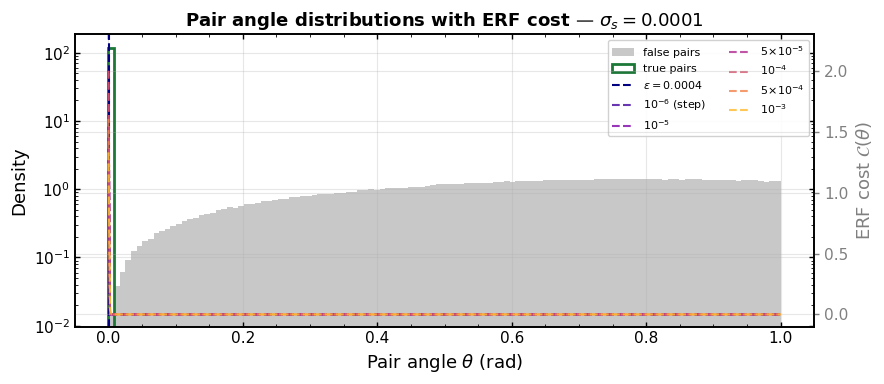

In [9]:
# §5 Angle distributions with ERF cost curves
# true_angles / false_angles are identical across theta_d (same physics),
# so we just pick the first populated cell from the cleanest noise pair.

def pool_angles(results_dir, sigma_scatt, sigma_res, max_pkls=15):
    """Pool true/false pair angles from the first available cell."""
    t_all, f_all, eps_val = [], [], None
    for td in THETA_D_GRID:
        tag_dir = results_dir / f"td{td:g}_ss{sigma_scatt:g}_sr{sigma_res:g}"
        pkls = sorted(tag_dir.glob('*.pkl')) if tag_dir.exists() else []
        for fp in pkls[:max_pkls]:
            try:
                r = pickle.load(open(fp, 'rb'))
            except Exception:
                continue
            if r.get('status') != 'ok':
                continue
            ta = r.get('true_angles')
            fa = r.get('false_angles')
            if ta is not None and len(ta):
                t_all.append(np.asarray(ta, dtype=float))
            if fa is not None and len(fa):
                f_all.append(np.asarray(fa, dtype=float))
            if eps_val is None:
                eps_val = float(r.get('epsilon', 0))
        if t_all:
            break  # one cell is enough — angles are physics, not model
    if not t_all:
        return None, None, None
    return np.concatenate(t_all), np.concatenate(f_all), eps_val

true_ang, false_ang, eps_val = pool_angles(RESULTS, ss0, sr0)

if true_ang is None:
    print('No angle data yet — run after at least one Condor job completes.')
else:
    fig, ax = plt.subplots(figsize=(9, 4))

    # angle histograms
    hi = min(float(np.percentile(false_ang, 99.5)), 1.0)
    bins = np.linspace(0, hi, 120)
    ax.hist(false_ang, bins=bins, color='0.75', alpha=0.85,
            label='false pairs', density=True)
    ax.hist(true_ang,  bins=bins, color=c_true, histtype='step',
            lw=2.0, label='true pairs', density=True)
    if eps_val:
        ax.axvline(eps_val, color='navy', ls='--', lw=1.5,
                   label=fr'$\varepsilon = {eps_val:.4f}$')
    ax.set_yscale('log')
    ax.set_xlabel(r'Pair angle $\theta$ (rad)')
    ax.set_ylabel('Density')

    # ERF cost curves on twin axis
    ax_r = ax.twinx()
    th_grid = np.linspace(0, hi, 400)
    for td, col, lab in zip(THETA_D_GRID, TD_COLORS, TD_LABELS):
        cost = 1.0 + scipy_erf((eps_val - th_grid) / (td * np.sqrt(2)))
        ax_r.plot(th_grid, cost, color=col, lw=1.5, ls='--', alpha=0.8,
                  label=lab)
    ax_r.set_ylabel(r'ERF cost $\mathcal{C}(\theta)$', color='grey')
    ax_r.set_ylim(-0.1, 2.3)
    ax_r.tick_params(axis='y', colors='grey')

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_r.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right',
              ncol=2, framealpha=0.9)
    ax.set_title(fr'Pair angle distributions with ERF cost — $\sigma_s={ss0:g}$',
                 fontweight='bold')
    _style(ax)
    fig.tight_layout()
    _save(fig, 'angle_dist_erf_overlay')
    plt.show()

## §6 Histogram-driven thresholds — Youden's J and EER

For each grid cell (erf_sigma, noise pair) pool all available `sol_C[truth]` and `sol_C[~truth]` scores across every rep and T, then find:

- **Youden's J** = $\max_\tau (\mathrm{TPR}(\tau) - \mathrm{FPR}(\tau))$ — optimal operating point for balanced sensitivity/specificity
- **EER** threshold — where $\mathrm{FPR} = 1 - \mathrm{TPR}$

The $\theta_d = 10^{-6}$ row is the regression baseline (should match the step-function τ ≈ 0.35·max).

In [10]:
# §6a Gather sol_C scores for each grid cell, compute optimal thresholds
def gather_cell_scores(results_dir, td, sigma_scatt, sigma_res):
    """Pool sol_C true/false scores across all reps and T for one grid cell."""
    t_all, f_all = [], []
    tag_dir = results_dir / f"td{td:g}_ss{sigma_scatt:g}_sr{sigma_res:g}"
    for fp in (sorted(tag_dir.glob('*.pkl')) if tag_dir.exists() else []):
        try:
            r = pickle.load(open(fp, 'rb'))
        except Exception:
            continue
        if r.get('status') != 'ok' or r.get('sol_C') is None:
            continue
        sC = np.asarray(r['sol_C'])
        tr = np.asarray(r['truth'], dtype=bool)
        t_all.append(sC[tr]); f_all.append(sC[~tr])
    if not t_all:
        return None, None
    return np.concatenate(t_all), np.concatenate(f_all)

def best_thresholds(ts, fs, n_grid=500):
    lo = min(ts.min(), fs.min()); hi = max(ts.max(), fs.max())
    grid = np.linspace(lo, hi, n_grid)
    tpr = np.array([(ts > t).mean() for t in grid])
    fpr = np.array([(fs > t).mean() for t in grid])
    j   = tpr - fpr
    eer_idx = np.argmin(np.abs(tpr - (1.0 - fpr)))
    return dict(
        youden_tau = float(grid[np.argmax(j)]),
        youden_J   = float(j.max()),
        eer_tau    = float(grid[eer_idx]),
        eer        = float((1.0 - tpr[eer_idx] + fpr[eer_idx]) / 2.0),
        tpr=tpr, fpr=fpr, grid=grid,
    )

thr_rows = []
for td in THETA_D_GRID:
    for ss, sr in NOISE_GRID:
        ts, fs = gather_cell_scores(RESULTS, td, ss, sr)
        if ts is None:
            continue
        r = best_thresholds(ts, fs)
        thr_rows.append(dict(
            erf_sigma=td, sigma_scatt=ss, sigma_res=sr,
            n_true=len(ts), n_false=len(fs),
            youden_tau=r['youden_tau'], youden_J=r['youden_J'],
            eer_tau=r['eer_tau'],       eer=r['eer'],
        ))

thr = pd.DataFrame(thr_rows)
if thr.empty:
    print('No score data for threshold analysis — run after jobs complete.')
else:
    with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 160):
        print(thr.to_string(index=False))

 erf_sigma  sigma_scatt  sigma_res  n_true  n_false  youden_tau  youden_J  eer_tau    eer
    0.0000       0.0001     0.0000     960    35040      0.2500    1.0000   0.2500 0.0000
    0.0000       0.0003     0.0100     960    35040      0.7665    0.9946   0.2615 0.0031
    0.0000       0.0005     0.0200     960    35040      0.5083    0.9916   0.2606 0.0052
    0.0000       0.0001     0.0000     960    35040      0.2525    0.9990   0.2525 0.0005
    0.0000       0.0003     0.0100     960    35040      0.5005    1.0000   0.5005 0.0000
    0.0000       0.0005     0.0200     960    35040      0.5055    0.9998   0.5055 0.0001
    0.0001       0.0001     0.0000     960    35040      0.2525    1.0000   0.2525 0.0000
    0.0001       0.0003     0.0100     960    35040      0.5055    0.9999   0.5055 0.0000
    0.0001       0.0005     0.0200     960    35040      0.5055    0.9999   0.5055 0.0000
    0.0001       0.0001     0.0000     960    35040      0.5004    1.0000   0.5004 0.0000
    0.0001

  -> figures/youden_eer_vs_td.{pdf,png}


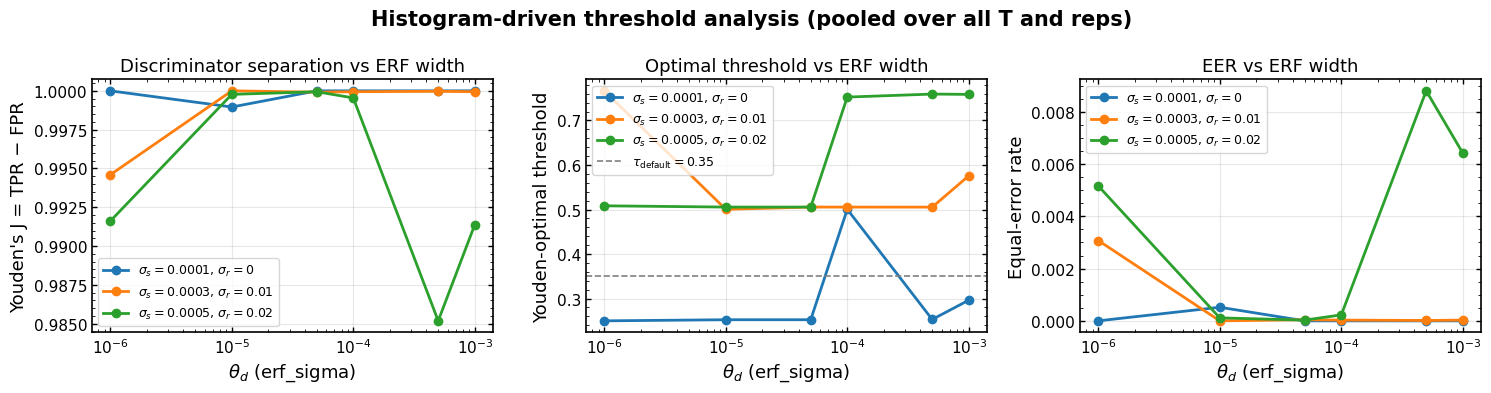

In [11]:
# §6b Youden's J and optimal threshold vs theta_d  (key ERF figure)
if not thr.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ax = axes[0]
    for (ss, sr), sub in thr.groupby(['sigma_scatt', 'sigma_res']):
        ax.plot(sub['erf_sigma'], sub['youden_J'], 'o-',
                label=fr'$\sigma_s={ss:g}$, $\sigma_r={sr:g}$')
    ax.set_xscale('log'); ax.set_xlabel(r'$\theta_d$ (erf_sigma)')
    ax.set_ylabel("Youden's J = TPR − FPR")
    ax.set_title('Discriminator separation vs ERF width')
    ax.legend(fontsize=9); _style(ax)

    ax = axes[1]
    for (ss, sr), sub in thr.groupby(['sigma_scatt', 'sigma_res']):
        ax.plot(sub['erf_sigma'], sub['youden_tau'], 'o-',
                label=fr'$\sigma_s={ss:g}$, $\sigma_r={sr:g}$')
    ax.axhline(TAU, color='grey', ls='--', lw=1.2,
               label=fr'$\tau_\mathrm{{default}}={TAU}$')
    ax.set_xscale('log'); ax.set_xlabel(r'$\theta_d$ (erf_sigma)')
    ax.set_ylabel('Youden-optimal threshold')
    ax.set_title('Optimal threshold vs ERF width')
    ax.legend(fontsize=9); _style(ax)

    ax = axes[2]
    for (ss, sr), sub in thr.groupby(['sigma_scatt', 'sigma_res']):
        ax.plot(sub['erf_sigma'], sub['eer'], 'o-',
                label=fr'$\sigma_s={ss:g}$, $\sigma_r={sr:g}$')
    ax.set_xscale('log'); ax.set_xlabel(r'$\theta_d$ (erf_sigma)')
    ax.set_ylabel('Equal-error rate')
    ax.set_title('EER vs ERF width')
    ax.legend(fontsize=9); _style(ax)

    fig.suptitle('Histogram-driven threshold analysis (pooled over all T and reps)',
                 fontweight='bold')
    fig.tight_layout()
    _save(fig, 'youden_eer_vs_td')
    plt.show()

## §7 Segment metrics vs $T$, coloured by $\theta_d$

Classical and quantum efficiency, FAR, purity, and cos(Q,C) at the **default** threshold ($\tau \cdot \max$).  
One figure per noise pair so the three operating regimes can be compared independently.

  -> figures/seg_metrics_ss0.0001_sr0.{pdf,png}


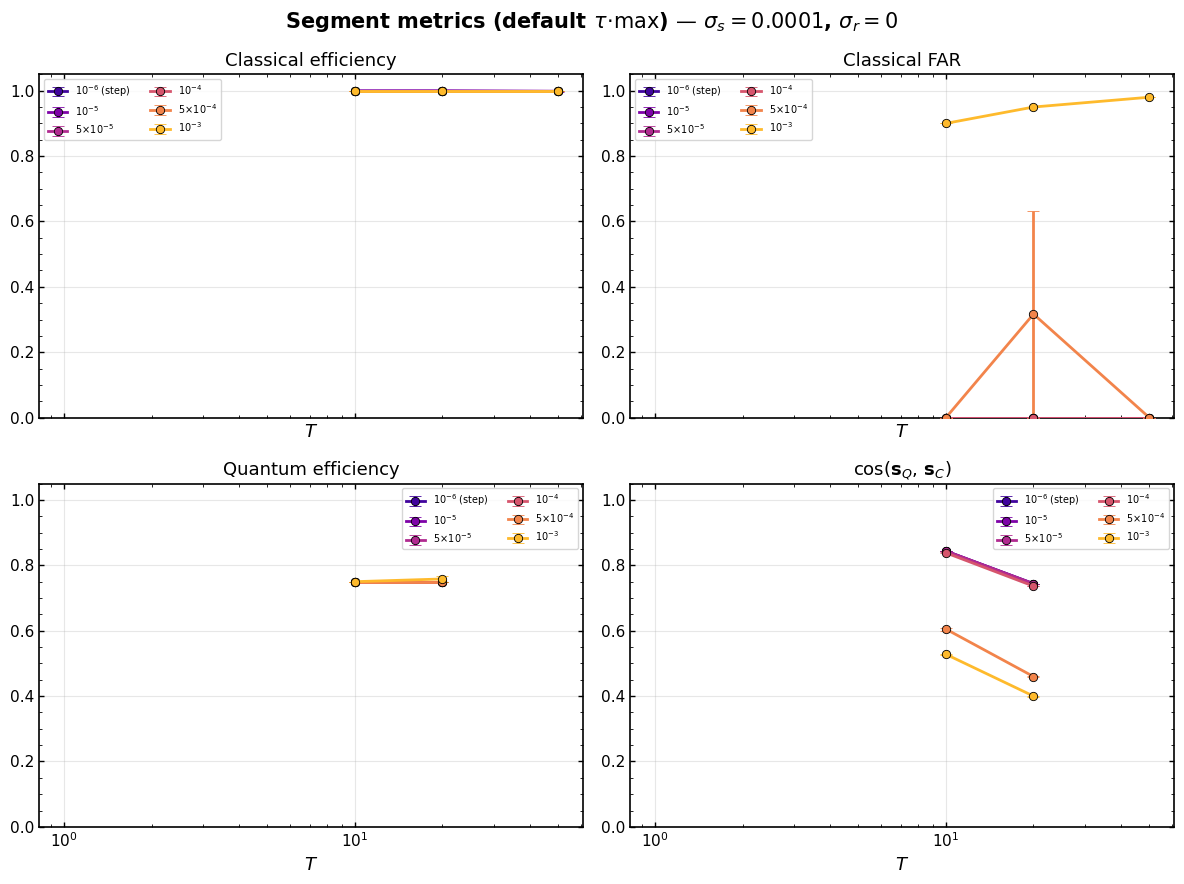

  -> figures/seg_metrics_ss0.0003_sr0.01.{pdf,png}


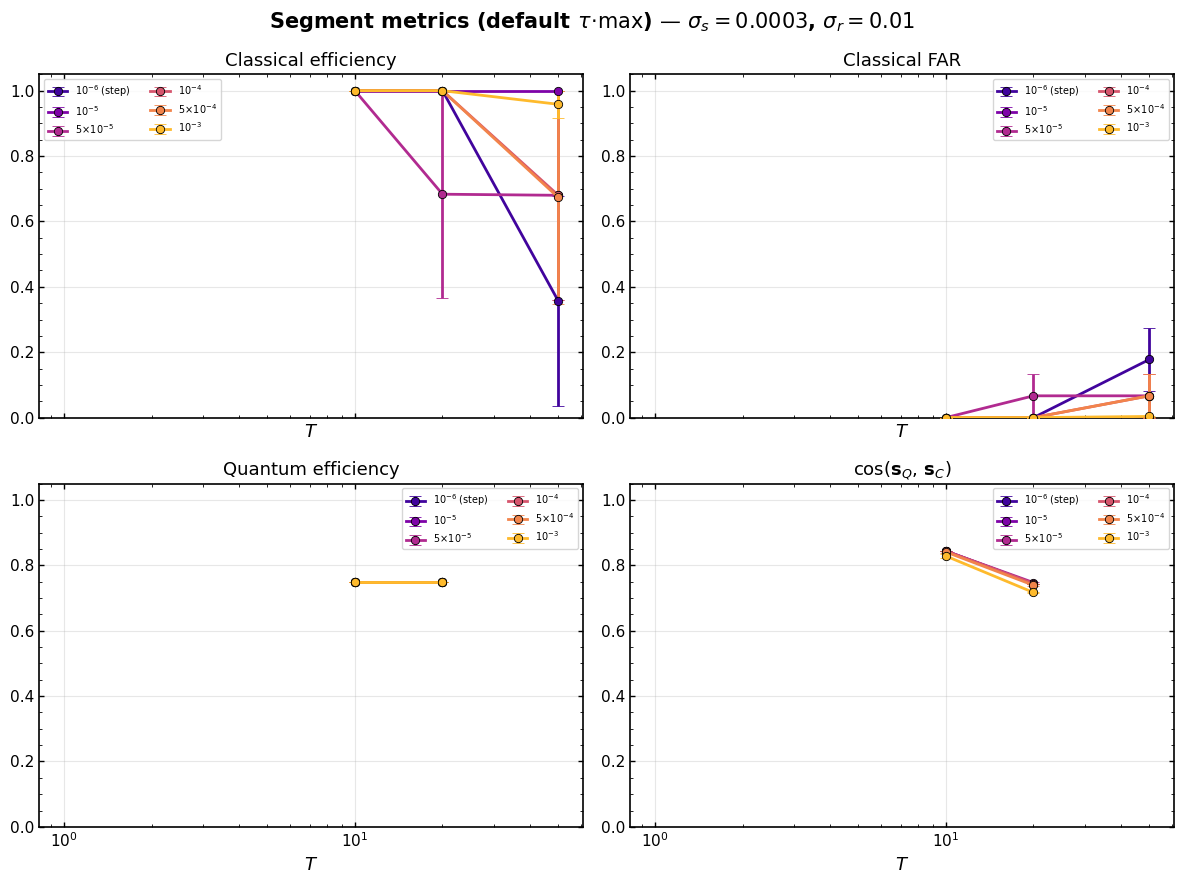

  -> figures/seg_metrics_ss0.0005_sr0.02.{pdf,png}


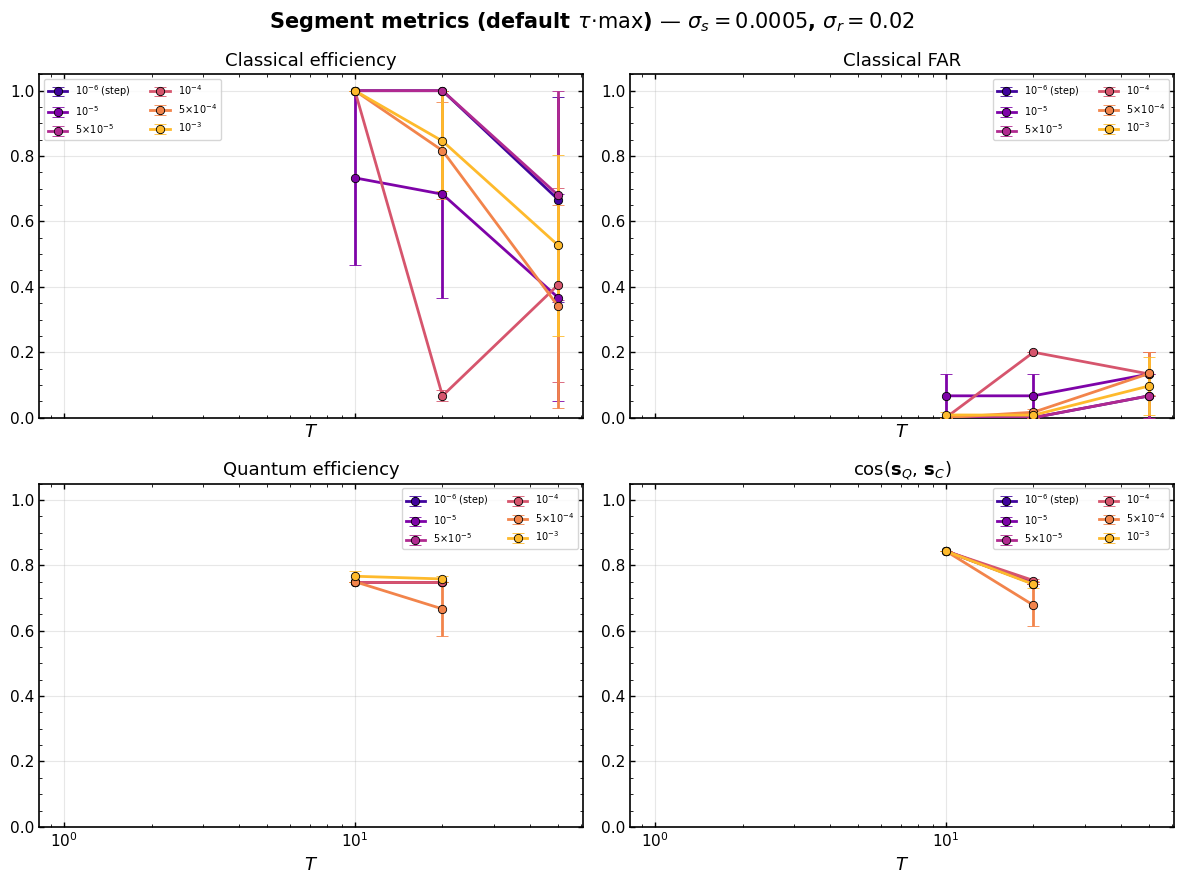

In [12]:
# §7 Aggregate per (erf_sigma, noise, n_trk) then plot
def sem(x):
    return float(x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 0.0

if ev.empty:
    print('No data yet.')
else:
    agg = (ev.groupby(['erf_sigma', 'sigma_scatt', 'sigma_res', 'n_trk'])
           .agg(
               cls_eff_mean=('cls_eff', 'mean'), cls_eff_sem=('cls_eff', sem),
               cls_pur_mean=('cls_pur', 'mean'), cls_pur_sem=('cls_pur', sem),
               cls_far_mean=('cls_far', 'mean'), cls_far_sem=('cls_far', sem),
               q_eff_mean  =('q_eff',   'mean'), q_eff_sem  =('q_eff',  sem),
               q_pur_mean  =('q_pur',   'mean'), q_pur_sem  =('q_pur',  sem),
               q_far_mean  =('q_far',   'mean'), q_far_sem  =('q_far',  sem),
               cos_mean    =('cos_QC',  'mean'), cos_sem    =('cos_QC', sem),
               n_reps      =('rep',    'count'),
           ).reset_index())

    PANEL_METRICS = [
        ('cls_eff', 'Classical efficiency',    (0.0, 1.05)),
        ('cls_far', 'Classical FAR',           (0.0, 1.05)),
        ('q_eff',   'Quantum efficiency',       (0.0, 1.05)),
        ('cos',     r'$\cos(\mathbf{s}_Q,\,\mathbf{s}_C)$', (0.0, 1.05)),
    ]

    for ss, sr in NOISE_GRID:
        sub_noise = agg[(agg.sigma_scatt == ss) & (agg.sigma_res == sr)]
        if sub_noise.empty:
            print(f'No data for ss={ss:g}, sr={sr:g}')
            continue

        fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
        for ax, (col, title, ylim) in zip(axes.ravel(), PANEL_METRICS):
            for td, c, lab in zip(THETA_D_GRID, TD_COLORS, TD_LABELS):
                row = sub_noise[sub_noise.erf_sigma == td].sort_values('n_trk')
                if row.empty:
                    continue
                _err(ax, row['n_trk'], row[f'{col}_mean'], row[f'{col}_sem'],
                     color=c, label=lab)
            ax.set_xscale('log'); ax.set_xlabel('$T$')
            ax.set_title(title); ax.set_ylim(*ylim)
            ax.legend(fontsize=7, ncol=2); _style(ax)

        fig.suptitle(fr'Segment metrics (default $\tau\!\cdot\!\max$) — '
                     fr'$\sigma_s={ss:g}$, $\sigma_r={sr:g}$',
                     fontweight='bold')
        fig.tight_layout()
        _save(fig, f'seg_metrics_ss{ss:g}_sr{sr:g}')
        plt.show()